# **"SkyGuard": Airport Security System**

### **The Scenario**
You have been hired by an international airport to evaluate a new AI scanning system called "SkyGuard." The vendor claims their system is revolutionary.
**The Pitch:** "Our system detects security threats (weapons, contraband) with **99.5% Accuracy**!"

Your job is to audit this claim. Is "Accuracy" the right metric when threats are extremely rare?

### **Knowledge Check**

**Question 1:** You analyze a day's worth of data: 1,000 passengers passed through the scanner.
* **995** were normal passengers (Safe).
* **5** were actual threats (carrying contraband).

The "SkyGuard" system is actually broken—it simply classifies **EVERYONE** as "Safe."
What is the numeric accuracy of this completely useless system?

A) 0%

B) 50%

C) 99.5%

D) 100%

Q1 Answer: C

Explanation: The system correctly classifies all 995 safe passengers but misses all 5 threats. Therefore, the accuracy is (995 correct predictions / 1000 total predictions) * 100% = 99.5%.

### **The Confusion Matrix**

To understand the performance better, we need a **Confusion Matrix**.
Recall the definitions:
* **True Positive (TP):** Threat detected correctly.
* **False Negative (FN):** Threat missed (let through). **Dangerous!**
* **False Positive (FP):** Innocent person flagged. (Annoying delay, but safe).
* **True Negative (TN):** Innocent person let through.

**Question 2:** In the "Airport Security" scenario, which error is the most critical to minimize, even if it increases the other type of error?

A) False Positives

B) False Negatives

C) True Negatives

D) Both are equally bad.

Answer: B False Negatives


Explanation: In airport security, a False Negative (missing a threat) can lead to dangerous situations, while a False Positive (flagging an innocent person) is less severe. Therefore, minimizing False Negatives is more critical.

### **Precision vs. Recall**

* **Precision:** Of all the people the AI *flagged* as threats, how many were actually threats?
    P = TP/(TP + FP)
    
* **Recall:** Of all the *actual* threats, how many did the AI catch?
    R = TP/T(P + FN)

**Question 3:** If you are tuning the "SkyGuard" system, which metric corresponds to "Catching as many terrorists as possible, regardless of false alarms"?

A) Precision

B) Recall

C) Accuracy

D) F-Score

Answer: B Recall

Explanation :
Recall measures how many actual threats the system successfully detects.
If the goal is to catch as many terrorists as possible, we must minimize false negatives (missed threats).
Even if it creates many false alarms (false positives), recall is the correct metric to maximize.


### **Interactive Challenge: Tuning the Threshold**

Real AI models don't just output "Safe" or "Threat." They output a **Risk Score** (e.g., probability from 0 to 100). We then pick a **Threshold** to make the final decision.

* **Low Threshold (e.g., 20):** We flag almost everyone. (High Recall, Low Precision)
* **High Threshold (e.g., 90):** We only flag the most obvious threats. (Low Recall, High Precision)

**Your Mission:**
The data below contains the "Risk Scores" for 30 passengers.
* **Passengers 0-4** are **Real Threats** (Scores: 85, 92, 75, 95, 65).
* **Passengers 5-25** are **Innocent** (Scores mostly low, but some nervous travelers have scores like 60, 70, 80).

**Task:**
1.  Run the code with `THRESHOLD = 50`. Observe the results.
2.  **Adjust the Threshold** to find the "Sweet Spot" where:
    * You catch **ALL 5** threats (**Recall = 1.0**).
    * You annoy the **fewest** innocent passengers (Maximize **Precision**).

In [51]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [52]:
# 1. Setup Risk Scores for 26 Passengers
# First 5 are Threats (High scores), Next 21 are Safe (Lower scores)
risk_scores = np.array([
    85, 92, 75, 95, 65,            # Threats (Real Danger)
    10, 20, 15, 5, 12, 8, 9, 11,   # Safe (Calm)
    40, 35, 30, 25, 20, 10, 5,     # Safe (Normal)
    60, 70, 80, 55, 15, 10         # Safe (Nervous/Outliers - These cause False Positives!)
])

# Ground Truth Labels (First 5 are 1, rest are 0)
y_true_small = np.zeros(26)
y_true_small[:5] = 1

In [ ]:
# --- STUDENT SECTION ---
# Change this value to tune the model!
THRESHOLD = 64

# Apply Threshold: If Score > Threshold, classify as 1 (Threat)
y_pred_tuned = (risk_scores > THRESHOLD).astype(int)

In [54]:
# Calculate Metrics
print(f"--- Results for Threshold = {THRESHOLD} ---")
print(f"Recall (Threats Caught):    {recall_score(y_true_small, y_pred_tuned):.2f}  (Goal: 1.0)")
print(f"Precision (True Alarms):    {precision_score(y_true_small, y_pred_tuned, zero_division=0):.2f}  (Goal: Maximize)")
print(f"False Alarms (FP):          {np.sum((y_pred_tuned == 1) & (y_true_small == 0))} innocent people stopped.")

--- Results for Threshold = 60 ---
Recall (Threats Caught):    1.00  (Goal: 1.0)
Precision (True Alarms):    0.71  (Goal: Maximize)
False Alarms (FP):          2 innocent people stopped.


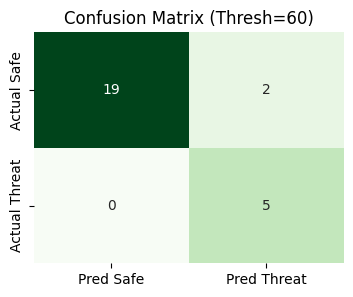

In [55]:
# Visualize
cm_tuned = confusion_matrix(y_true_small, y_pred_tuned)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Safe', 'Pred Threat'],
            yticklabels=['Actual Safe', 'Actual Threat'])
plt.title(f"Confusion Matrix (Thresh={THRESHOLD})")
plt.show()